In [ ]:
# Ячейка 1: Импорты и константы
import os
import cv2
import numpy as np
import pandas as pd
import albumentations as A
from albumentations.pytorch import ToTensorV2
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
import random
from collections import defaultdict

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

BASE_PATH = '/home/shizm/DL_LABs/DL-lab4/dl-lab-4-ocr/'
TRAIN_IMG_DIR = os.path.join(BASE_PATH, 'train', 'train')
TARGET_HEIGHT = 32
BATCH_SIZE = 128
NUM_WORKERS = 4
N_FOLDS = 10
N_EPOCHS = 100
LEARNING_RATE = 1e-3
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"Устройство: {DEVICE}")

Устройство: cuda


In [26]:
# Ячейка 2: Алфавит и кодирование
ALPHABET = '0123456789'
CHAR_TO_IDX = {char: idx + 1 for idx, char in enumerate(ALPHABET)}
IDX_TO_CHAR = {idx + 1: char for idx, char in enumerate(ALPHABET)}
BLANK_IDX = 0
NUM_CLASSES = len(ALPHABET) + 1

def encode_price(price_str):
    indices = [CHAR_TO_IDX[char] for char in price_str]
    return torch.tensor(indices, dtype=torch.long)

print(f"Количество классов (с blank): {NUM_CLASSES}")

Количество классов (с blank): 11


In [27]:
# Ячейка 3: УЛУЧШЕННЫЕ АУГМЕНТАЦИИ
train_transforms = A.Compose([
    A.Rotate(limit=40, border_mode=cv2.BORDER_CONSTANT, value=0, p=0.1),
    A.ElasticTransform(alpha=1, sigma=50, alpha_affine=50, p=0.3),
    A.GaussianBlur(blur_limit=(3), p=0.3),
    A.GaussNoise(var_limit=(10.0, 40.0), p=0.2),
    A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3, p=0.5),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
])

val_transforms = A.Compose([
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
])

/home/shizm/DL_LABs/.venv/lib/python3.12/site-packages/albumentations/augmentations/blur/transforms.py:184: UserWarning: blur_limit and sigma_limit minimum value can not be both equal to 0. blur_limit minimum value changed to 3.
  warnings.warn(


In [28]:
# Ячейка 4: Dataset и collate_fn (без изменений)
class OCRDataset(Dataset):
    def __init__(self, df, img_dir, transforms=None, target_height=TARGET_HEIGHT):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transforms = transforms
        self.target_height = target_height

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.img_dir, row['Filename'])
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        h, w = image.shape[:2]
        new_w = int(w * (self.target_height / h))
        image = cv2.resize(image, (new_w, self.target_height), interpolation=cv2.INTER_LINEAR)
        
        if self.transforms:
            augmented = self.transforms(image=image)
            image = augmented['image']
        
        price_str = str(row['price_str'])
        label = encode_price(price_str)
        return image, label, len(label)

def collate_fn(batch):
    images, labels, label_lengths = zip(*batch)
    max_width = max(img.shape[2] for img in images)
    padded_images = []
    for img in images:
        c, h, w = img.shape
        pad_w = max_width - w
        if pad_w > 0:
            padding = torch.zeros(c, h, pad_w)
            img = torch.cat([img, padding], dim=2)
        padded_images.append(img)
    images = torch.stack(padded_images, 0)
    labels = torch.cat(labels)
    label_lengths = torch.tensor(label_lengths)
    return images, labels, label_lengths

In [29]:
# Ячейка 5: Модель CRNN (без изменений)
class CRNN(nn.Module):
    def __init__(self, num_classes, input_channels=3, hidden_size=256):
        super().__init__()
        
        self.cnn = nn.Sequential(
            nn.Conv2d(input_channels, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=(2, 1), stride=(2, 1)),
            
            nn.Conv2d(256, 512, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=(2, 1), stride=(2, 1)),
            
            nn.AdaptiveAvgPool2d((1, None))
        )
        
        self.cnn_output_channels = 512
        
        self.lstm = nn.LSTM(
            input_size=self.cnn_output_channels,
            hidden_size=hidden_size,
            num_layers=2,
            bidirectional=True,
            batch_first=True
        )
        
        self.fc = nn.Linear(hidden_size * 2, num_classes)
    
    def forward(self, x):
        conv_features = self.cnn(x)
        conv_features = conv_features.squeeze(2)
        conv_features = conv_features.permute(0, 2, 1)
        lstm_out, _ = self.lstm(conv_features)
        logits = self.fc(lstm_out)
        logits = logits.permute(1, 0, 2)
        return logits

In [30]:
# Ячейка 6: Метрики и декодирование
import editdistance

def decode_predictions(logits, blank_idx=BLANK_IDX):
    logits = logits.permute(1, 0, 2)
    _, max_indices = torch.max(logits, dim=2)
    decoded = []
    for indices in max_indices:
        chars = []
        prev = blank_idx
        for idx in indices:
            idx = idx.item()
            if idx != blank_idx and idx != prev:
                chars.append(IDX_TO_CHAR[idx])
            prev = idx
        decoded.append(''.join(chars))
    return decoded

def compute_cer(pred_strings, target_strings):
    total_errors = 0
    total_chars = 0
    for pred, target in zip(pred_strings, target_strings):
        if len(pred) == 0 and len(target) == 0:
            continue
        errors = editdistance.eval(pred, target)
        total_errors += errors
        total_chars += len(target)
    return total_errors / max(total_chars, 1)

In [31]:
def train_one_fold(fold, train_df, n_epochs=N_EPOCHS, lr=LEARNING_RATE):
    print(f"\n{'='*20} Обучение фолда {fold} {'='*20}")
    
    train_data = train_df[train_df['fold'] != fold]
    val_data = train_df[train_df['fold'] == fold]
    
    train_dataset = OCRDataset(train_data, TRAIN_IMG_DIR, transforms=train_transforms)
    val_dataset = OCRDataset(val_data, TRAIN_IMG_DIR, transforms=val_transforms)
    
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                              collate_fn=collate_fn, num_workers=NUM_WORKERS)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                            collate_fn=collate_fn, num_workers=NUM_WORKERS)
    
    model = CRNN(num_classes=NUM_CLASSES).to(DEVICE)
    
    if os.path.exists(f'crnn_fold_{fold}.pth'):
        model.load_state_dict(torch.load(f'crnn_fold_{fold}.pth', map_location=DEVICE))
        print(f"Загружены предобученные веса для фолда {fold}")
    
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    steps_per_epoch = len(train_loader)
    total_steps = steps_per_epoch * n_epochs
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer,
        max_lr=3e-3,
        total_steps=total_steps,
        pct_start=0.1,
        anneal_strategy='cos'
    )
    
    ctc_loss = nn.CTCLoss(blank=BLANK_IDX, zero_infinity=True)
    
    best_cer = float('inf')
    best_model_state = None
    history = {'train_loss': [], 'val_loss': [], 'val_cer': []}
    
    for epoch in range(1, n_epochs + 1):
        model.train()
        train_loss = 0.0
        pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{n_epochs} [Train]")
        for images, labels, label_lengths in pbar:
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)
            label_lengths = label_lengths.to(DEVICE)
            
            optimizer.zero_grad()
            logits = model(images)
            input_lengths = torch.full((images.size(0),), logits.size(0), dtype=torch.long).to(DEVICE)
            loss = ctc_loss(logits, labels, input_lengths, label_lengths)
            loss.backward()
            optimizer.step()
            scheduler.step()
            
            train_loss += loss.item()
            pbar.set_postfix(loss=f"{loss.item():.4f}", lr=f"{scheduler.get_last_lr()[0]:.2e}")
        
        avg_train_loss = train_loss / len(train_loader)
        history['train_loss'].append(avg_train_loss)
        
        model.eval()
        val_loss = 0.0
        all_preds = []
        all_targets = []
        with torch.no_grad():
            for images, labels, label_lengths in val_loader:
                images = images.to(DEVICE)
                labels = labels.to(DEVICE)
                label_lengths = label_lengths.to(DEVICE)
                
                logits = model(images)
                input_lengths = torch.full((images.size(0),), logits.size(0), dtype=torch.long).to(DEVICE)
                loss = ctc_loss(logits, labels, input_lengths, label_lengths)
                val_loss += loss.item()
                
                pred_strings = decode_predictions(logits)
                target_strings = []
                start = 0
                for length in label_lengths:
                    target_indices = labels[start:start+length].tolist()
                    target_strings.append(''.join(IDX_TO_CHAR[idx] for idx in target_indices))
                    start += length
                all_preds.extend(pred_strings)
                all_targets.extend(target_strings)
        
        avg_val_loss = val_loss / len(val_loader)
        cer = compute_cer(all_preds, all_targets)
        history['val_loss'].append(avg_val_loss)
        history['val_cer'].append(cer)
        
        print(f"Epoch {epoch}: train_loss={avg_train_loss:.4f}, val_loss={avg_val_loss:.4f}, val_cer={cer:.4f}")
        
        if cer < best_cer:
            best_cer = cer
            best_model_state = model.state_dict().copy()
            print(f"  -> Сохранена лучшая модель (val_cer={best_cer:.4f})")
    
    torch.save(best_model_state, f'crnn_fold_{fold}_improved.pth')
    print(f"Фолд {fold} завершён. Лучший val_cer: {best_cer:.4f}")
    
    return best_cer, history

In [32]:
# Ячейка 8: Запуск обучения
train_df = pd.read_csv('train_with_10folds.csv')
train_df['price_str'] = train_df['price_str'].astype(str)

print(f"Всего примеров: {len(train_df)}")
print("Распределение по фолдам:")
print(train_df['fold'].value_counts().sort_index())

fold_results = {}

for fold in range(N_FOLDS):
    val_loss, history = train_one_fold(fold, train_df, n_epochs=N_EPOCHS, lr=LEARNING_RATE)
    fold_results[fold] = {'val_loss': val_loss, 'history': history}

print("\n" + "-"*50)
print("Результаты кросс-валидации:")
for fold, res in fold_results.items():
    print(f"Фолд {fold}: лучший val_loss = {res['val_loss']:.4f}")
print(f"Средний val_loss: {np.mean([r['val_loss'] for r in fold_results.values()]):.4f}")

Всего примеров: 15050
Распределение по фолдам:
fold
0    1534
1    1494
2    1499
3    1494
4    1498
5    1495
6    1500
7    1510
8    1510
9    1516
Name: count, dtype: int64

==================== Обучение фолда 0 ====================


Epoch 1/100 [Train]: 100%|██████████| 106/106 [00:06<00:00, 15.32it/s, loss=3.1386, lr=1.91e-04]


Epoch 1: train_loss=2.1679, val_loss=2.9635, val_cer=1.0000
  -> Сохранена лучшая модель (val_cer=1.0000)


Epoch 2/100 [Train]: 100%|██████████| 106/106 [00:06<00:00, 15.26it/s, loss=2.5834, lr=3.96e-04]


Epoch 2: train_loss=2.6308, val_loss=2.6499, val_cer=1.0000


...

Epoch 98: train_loss=0.4695, val_loss=0.0494, val_cer=0.0081


Epoch 99/100 [Train]: 100%|██████████| 106/106 [00:06<00:00, 15.40it/s, loss=0.4311, lr=9.09e-07]


Epoch 99: train_loss=0.4581, val_loss=0.0496, val_cer=0.0081


Epoch 100/100 [Train]: 100%|██████████| 106/106 [00:06<00:00, 15.41it/s, loss=0.5300, lr=1.21e-08]


Epoch 100: train_loss=0.4597, val_loss=0.0500, val_cer=0.0081
Фолд 9 завершён. Лучший val_cer: 0.0068

--------------------------------------------------
Результаты кросс-валидации:
Фолд 0: лучший val_loss = 0.0042
Фолд 1: лучший val_loss = 0.0037
Фолд 2: лучший val_loss = 0.0050
Фолд 3: лучший val_loss = 0.0045
Фолд 4: лучший val_loss = 0.0050
Фолд 5: лучший val_loss = 0.0042
Фолд 6: лучший val_loss = 0.0065
Фолд 7: лучший val_loss = 0.0061
Фолд 8: лучший val_loss = 0.0042
Фолд 9: лучший val_loss = 0.0068
Средний val_loss: 0.0050


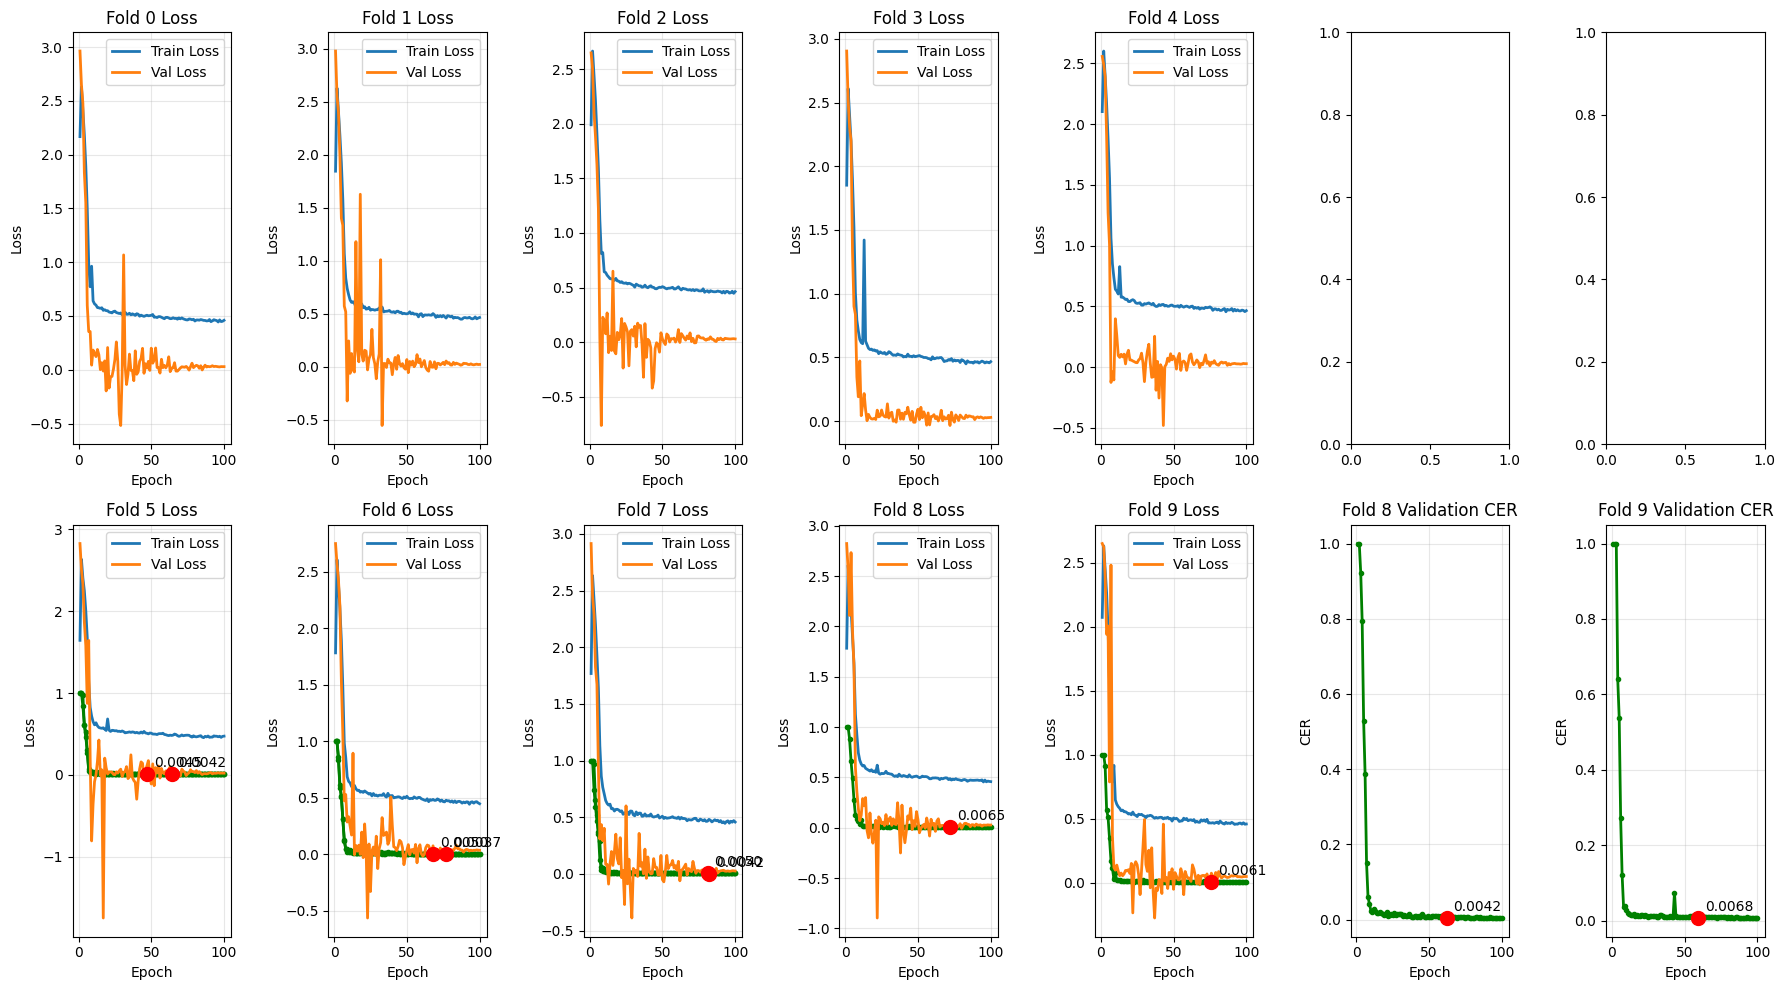

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict

# Ячейка 1: Подробные графики обучения для каждого фолда
def plot_training_history(fold_results):
    fig, axes = plt.subplots(2, 7, figsize=(18, 10))
    
    for fold, res in fold_results.items():
        history = res['history']
        epochs = range(1, len(history['train_loss']) + 1)
        
        # Loss
        ax = axes[0, fold] if fold < 5 else axes[1, fold-5]
        ax.plot(epochs, history['train_loss'], label='Train Loss', linewidth=2)
        ax.plot(epochs, history['val_loss'], label='Val Loss', linewidth=2)
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Loss')
        ax.set_title(f'Fold {fold} Loss')
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        # CER на втором ряду
        ax2 = axes[1, fold] if fold < 3 else axes[1, fold-3]
        ax2.plot(epochs, history['val_cer'], color='green', linewidth=2, marker='o', markersize=3)
        ax2.set_xlabel('Epoch')
        ax2.set_ylabel('CER')
        ax2.set_title(f'Fold {fold} Validation CER')
        ax2.grid(True, alpha=0.3)
        
        # Отмечаем лучший CER
        best_epoch = np.argmin(history['val_cer']) + 1
        best_cer = min(history['val_cer'])
        ax2.scatter(best_epoch, best_cer, color='red', s=100, zorder=5)
        ax2.annotate(f'{best_cer:.4f}', (best_epoch, best_cer), 
                     xytext=(5, 5), textcoords='offset points', fontsize=10)
    
    
    
    plt.tight_layout()
    plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_training_history(fold_results)

In [39]:
# Ячейка 2: Анализ ошибок на валидации для лучшей модели
def analyze_errors(model, val_loader, device, num_examples=20):
    """
    Выводит примеры, на которых модель ошибается.
    """
    model.eval()
    errors = []
    
    with torch.no_grad():
        for images, labels, label_lengths in val_loader:
            images = images.to(device)
            labels = labels.to(device)
            label_lengths = label_lengths.to(device)
            
            logits = model(images)
            pred_strings = decode_predictions(logits)
            
            # Восстанавливаем true метки
            target_strings = []
            start = 0
            for length in label_lengths:
                target_indices = labels[start:start+length].tolist()
                target_strings.append(''.join(IDX_TO_CHAR[idx] for idx in target_indices))
                start += length
            
            # Собираем ошибки
            for i, (pred, target) in enumerate(zip(pred_strings, target_strings)):
                if pred != target:
                    errors.append({
                        'image': images[i].cpu(),
                        'pred': pred,
                        'target': target,
                        'confidence': torch.softmax(logits[:, i, :], dim=1).max(dim=1)[0].mean().item()
                    })
            
            if len(errors) >= num_examples * 2:  # собираем с запасом
                break
    
    return errors[:num_examples]

# Загружаем лучшую модель (например, фолда 0)
best_model = CRNN(num_classes=NUM_CLASSES).to(DEVICE)
best_model.load_state_dict(torch.load('crnn_fold_0_improved.pth'))
best_model.eval()

# Анализируем ошибки на валидации фолда 0
val_data = train_df[train_df['fold'] == 0]
val_dataset = OCRDataset(val_data, TRAIN_IMG_DIR, transforms=val_transforms)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, collate_fn=collate_fn, num_workers=2)

errors = analyze_errors(best_model, val_loader, DEVICE, num_examples=20)

/tmp/ipykernel_6052/4163624947.py:43: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  best_model.load_state_dict(torch.load('crnn_fold_0_improved.pth'))


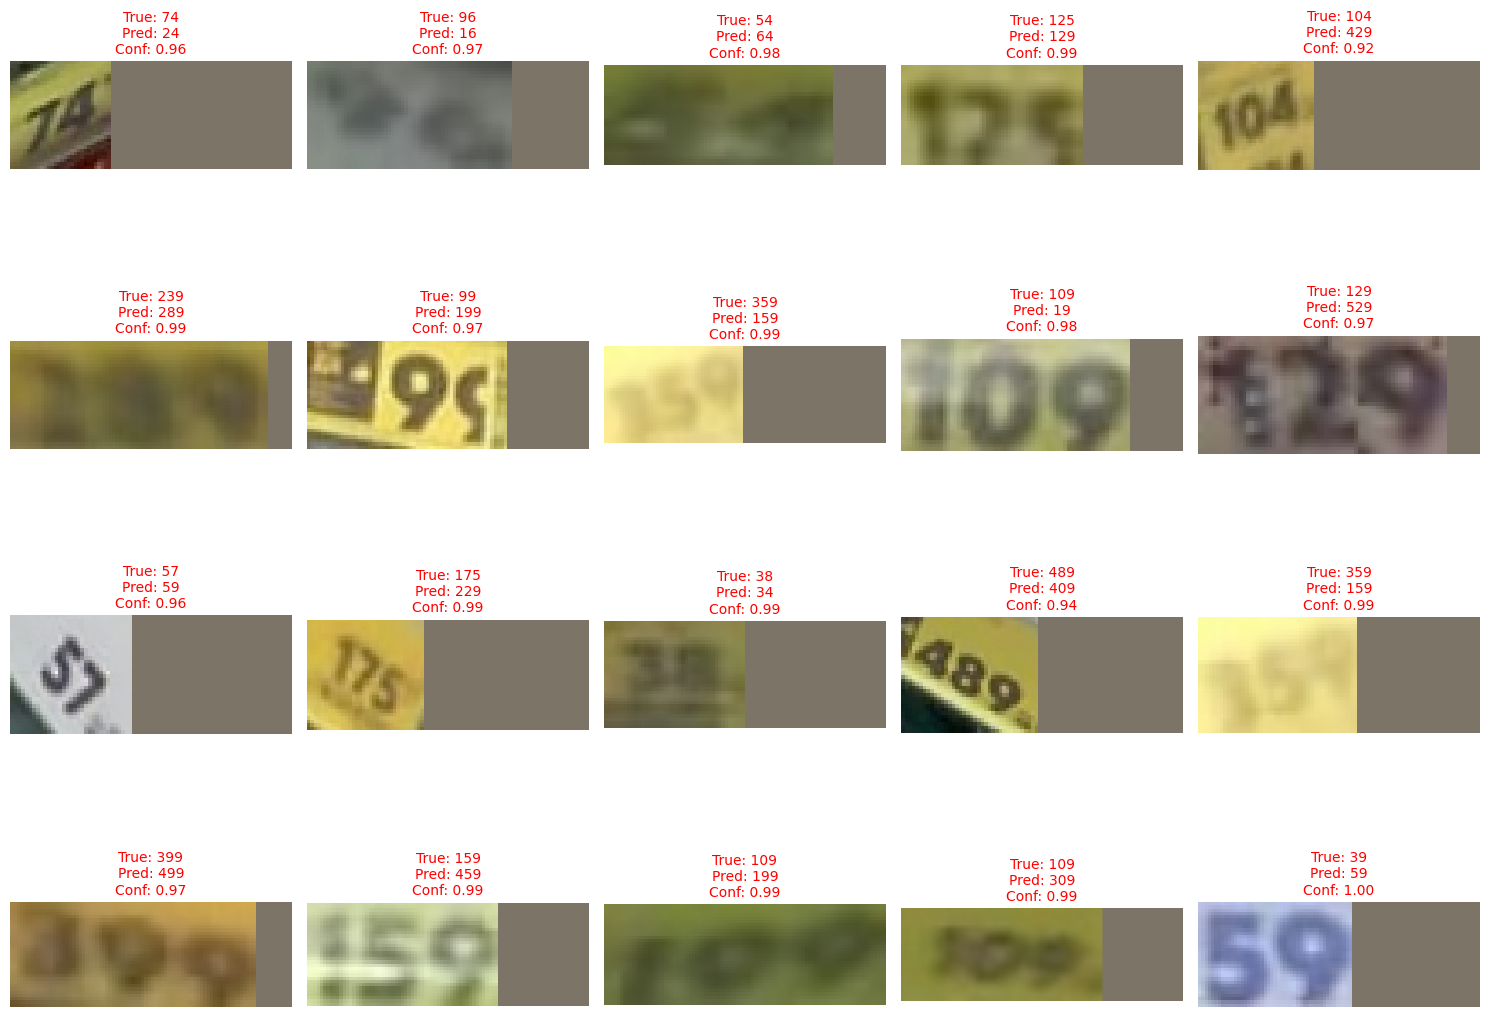

In [40]:
# Ячейка 3: Визуализация ошибок
def visualize_errors(errors, num_cols=5):
    num_rows = (len(errors) + num_cols - 1) // num_cols
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(num_cols*3, num_rows*3))
    axes = axes.flatten()
    
    # Денормализация
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    
    for i, err in enumerate(errors):
        img = err['image'].permute(1, 2, 0).numpy()
        img = img * std + mean
        img = np.clip(img, 0, 1)
        
        axes[i].imshow(img)
        axes[i].set_title(f"True: {err['target']}\nPred: {err['pred']}\nConf: {err['confidence']:.2f}", 
                          fontsize=10, color='red')
        axes[i].axis('off')
    
    for j in range(i+1, len(axes)):
        axes[j].axis('off')
    
    plt.tight_layout()
    plt.savefig('error_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()

visualize_errors(errors)

In [41]:
# Ячейка 4: Статистика по типам ошибок
def categorize_error(pred, target):
    if len(pred) == 0:
        return 'empty_pred'
    if len(pred) < len(target):
        return 'missing_digit'
    if len(pred) > len(target):
        return 'extra_digit'
    if len(pred) == len(target):
        diff_positions = [i for i, (p, t) in enumerate(zip(pred, target)) if p != t]
        if len(diff_positions) == 1:
            return f'substitution_{target[diff_positions[0]]}->{pred[diff_positions[0]]}'
        else:
            return 'multi_substitution'
    return 'other'

error_stats = defaultdict(int)
confusion_pairs = defaultdict(int)

for err in errors:
    err_type = categorize_error(err['pred'], err['target'])
    error_stats[err_type] += 1
    
    if 'substitution' in err_type:
        # Извлекаем пару цифр
        parts = err_type.split('_')[1]
        confusion_pairs[parts] += 1

print("Статистика по типам ошибок:")
for err_type, count in sorted(error_stats.items(), key=lambda x: -x[1]):
    print(f"  {err_type}: {count}")

print("\nТоп-5 путаемых пар цифр:")
for pair, count in sorted(confusion_pairs.items(), key=lambda x: -x[1])[:5]:
    print(f"  {pair}: {count}")

Статистика по типам ошибок:
  multi_substitution: 2
  substitution_3->1: 2
  substitution_7->2: 1
  substitution_9->1: 1
  substitution_5->6: 1
  substitution_5->9: 1
  substitution_3->8: 1
  extra_digit: 1
  missing_digit: 1
  substitution_1->5: 1
  substitution_7->9: 1
  substitution_8->4: 1
  substitution_8->0: 1
  substitution_3->4: 1
  substitution_1->4: 1
  substitution_0->9: 1
  substitution_1->3: 1
  substitution_3->5: 1

Топ-5 путаемых пар цифр:
  substitution: 2
  3->1: 2
  7->2: 1
  9->1: 1
  5->6: 1
